In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import glob
import random
import json
import cv2
import pickle

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
from pathlib import Path

In [ ]:
# Clonando o repositório
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

# Movendo para o diretório do dataset
%cd PlantVillage-Dataset/raw/color

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163235, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 163235 (delta 2), reused 0 (delta 0), pack-reused 163229 (from 1)
Receiving objects: 100% (163235/163235), 2.00 GiB | 33.35 MiB/s, done.
Resolving deltas: 100% (101/101), done.
Updating files: 100% (182401/182401), done.
/content/PlantVillage-Dataset/raw/color


In [ ]:
# PATHS

# Caminhos dos arquivos de historico e dos pesos
dataset = '/content/PlantVillage-Dataset/raw/color'
history_path = '/content/drive/MyDrive/CLOROFILA/history/history.json'
historico_pkl_path = '/content/drive/MyDrive/CLOROFILA/history/history.pkl'
checkpoint_dir = "/content/drive/MyDrive/CLOROFILA/checkpoints"

# Caminhos dos arquivos salvos anteriormente
y_true_path = '/content/drive/MyDrive/CLOROFILA/y_true.npy'
y_pred_path = '/content/drive/MyDrive/CLOROFILA/y_pred.npy'
class_names_path = '/content/drive/MyDrive/CLOROFILA/class_names.npy'

# Caminhos para salvar as imagens plotadas
inference_dir = "/content/drive/MyDrive/CLOROFILA/inferences/inferencias.png"
error_dir = "/content/drive/MyDrive/CLOROFILA/erros_classificacao.png"
matrix_dir = "/content/drive/MyDrive/CLOROFILA/matriz_confusao_nomes.png"

# Define número total de épocas desejadas
total_epochs = 100
save_points = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Definindo parâmetros
img_height, img_width = 128, 128
batch_size = 32

In [ ]:
# DATASET

# Data augmentation para o treino e apenas normalização para validação
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Gerador para dados de treinamento (com augmentations)
train_generator = train_datagen.flow_from_directory(
    dataset,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse',
    subset='training',
    shuffle=True
)

# Gerador para dados de validação (sem augmentations)
val_generator = val_datagen.flow_from_directory(
    dataset,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [ ]:
# HISTORY E CHECKPOINT

# Carrega histórico anterior se existir

history_data = {}
os.makedirs(checkpoint_dir, exist_ok=True)
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history_data = json.load(f)

# Verifica o último checkpoint salvo
checkpoint_files = sorted([f for f in os.listdir(checkpoint_dir) if f.endswith(".weights.h5")])

if checkpoint_files:
    last_checkpoint = os.path.join(checkpoint_dir, checkpoint_files[-1])
    print(f"Carregando pesos de: {last_checkpoint}")
    model.load_weights(last_checkpoint)
    last_epoch = int(checkpoint_files[-1].split("-")[1].split(".")[0])
else:
    last_epoch = 0

# Configuração do callback
checkpoint_path = os.path.join(checkpoint_dir, "cp-{epoch:02d}.weights.h5")
cp_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    verbose=1,
    save_freq='epoch'
)

# Filtra os blocos que ainda não foram treinados
save_points = [ep for ep in save_points if ep > last_epoch]

print(f"Início do próximo treinamento a partir da época: {last_epoch + 1}")
print(f"Histórico carregado de: {history_path}")

In [ ]:
# MODEL

# Definicao do modelo

model = models.Sequential([
    layers.InputLayer(input_shape=(img_height, img_width, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# TRAIN
# Compila o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Treinamento em blocos
for epoch_block in save_points:
    print(f"\nTreinando de {last_epoch+1} até {epoch_block}...")

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        initial_epoch=last_epoch,
        epochs=epoch_block,
        callbacks=[cp_callback],
        verbose=1
    )

    # Atualiza o histórico acumulado
    for key in history.history:
        if key in history_data:
            history_data[key] += history.history[key]
        else:
            history_data[key] = history.history[key]

    # Salva histórico em JSON e pickle
    with open(history_path, 'w') as f_json:
        json.dump(history_data, f_json)

    with open(historico_pkl_path.replace(".pkl", f"_{epoch_block}.pkl"), 'wb') as f_pkl:
        pickle.dump(history_data, f_pkl)

    # Salva modelo completo
    model.save(f'/content/drive/MyDrive/CLOROFILA/modelo_{epoch_block}.h5')

    last_epoch = epoch_block


Treinando de 61 até 80...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 61/80
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9825 - loss: 0.0652
Epoch 61: saving model to /content/drive/MyDrive/CLOROFILA/checkpoints/cp-61.weights.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 237s 171ms/step - accuracy: 0.9825 - loss: 0.0652 - val_accuracy: 0.9747 - val_loss: 0.1287
Epoch 62/80
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9838 - loss: 0.0593
Epoch 62: saving model to /content/drive/MyDrive/CLOROFILA/checkpoints/cp-62.weights.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 220s 162ms/step - accuracy: 0.9838 - loss: 0.0593 - val_accuracy: 0.9738 - val_loss: 0.1169
Epoch 63/80
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9808 - loss: 0.0677
Epoch 63: saving model to /content/drive/MyDrive/CLOROFILA/checkpoints/cp-63.weights.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 213s 157ms/step - accuracy: 0.9808 - loss: 0.0677 - val_accuracy: 0.9667 - val_loss: 0.1611
Epoch 64/80
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9830 - loss: 0.0581
Epo

In [ ]:
# Avaliação final
val_loss, val_acc = model.evaluate(val_generator)
print(f"Acurácia final na validação: {val_acc:.2%}")

NameError: name 'model' is not defined

In [ ]:
# RESULTS

# Geração de y_true, y_pred e nomes das classes
y_true = val_generator.classes
y_prob = model.predict(val_generator)
y_pred = np.argmax(y_prob, axis=1)

# Verifica se os arquivos anteriores existem e concatena
if os.path.exists(y_true_path) and os.path.exists(y_pred_path):
    y_true_antigo = np.load(y_true_path)
    y_pred_antigo = np.load(y_pred_path)

    y_true = np.concatenate([y_true_antigo, y_true])
    y_pred = np.concatenate([y_pred_antigo, y_pred])

# Salva os dados atualizados
np.save(y_true_path, y_true)
np.save(y_pred_path, y_pred)

# Salva os nomes das classes apenas uma vez (caso ainda não exista)
if not os.path.exists(class_names_path):
    np.save(class_names_path, list(val_generator.class_indices.keys()))


340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


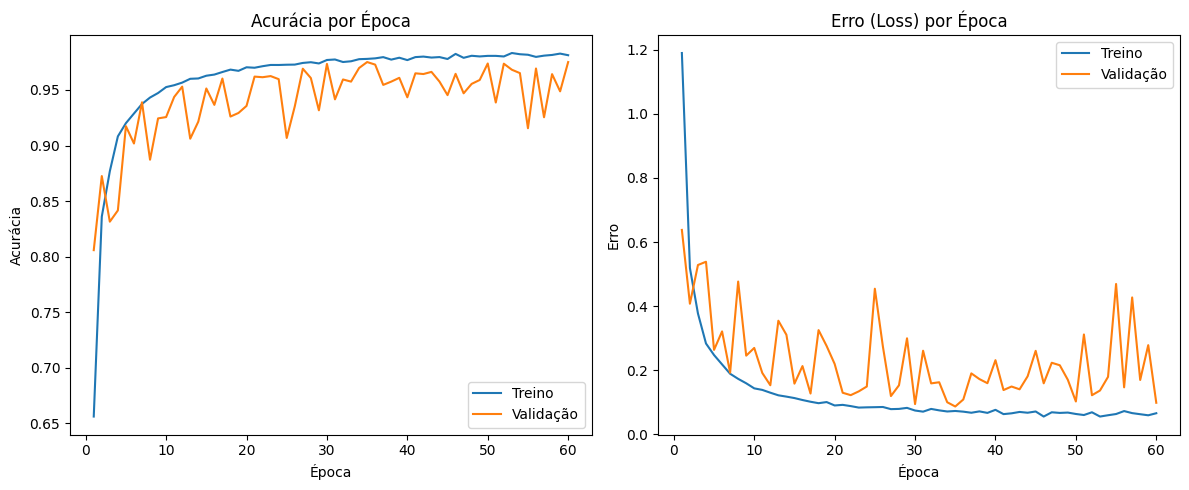

In [ ]:
# Plotar gráficos
epochs = range(1, len(history_data['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# Gráfico de acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs, history_data['accuracy'], label='Treino')
plt.plot(epochs, history_data['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

# Gráfico de erro
plt.subplot(1, 2, 2)
plt.plot(epochs, history_data['loss'], label='Treino')
plt.plot(epochs, history_data['val_loss'], label='Validação')
plt.title('Erro (Loss) por Época')
plt.xlabel('Época')
plt.ylabel('Erro')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


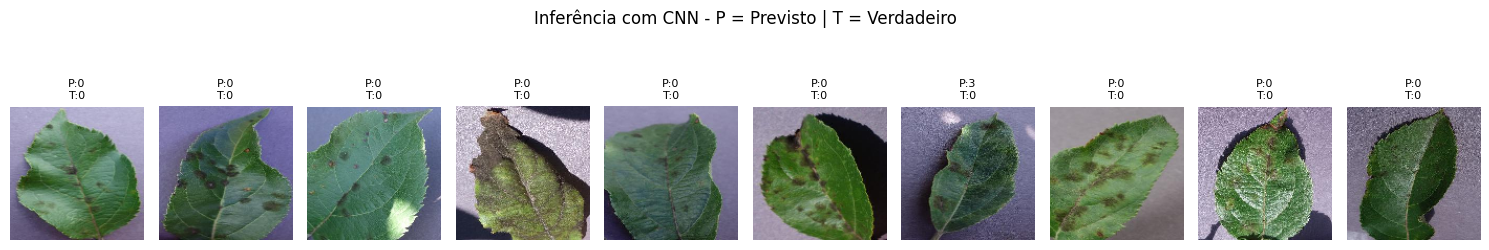

In [ ]:
# Obtém um lote do gerador de validação
x_batch, y_batch = next(val_generator)

# Faz previsões
predictions = model.predict(x_batch)

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_batch[i])
    pred_label = np.argmax(predictions[i])
    true_label = int(y_batch[i])
    plt.title(f"P:{pred_label}\nT:{true_label}", fontsize=8)
    plt.axis('off')

plt.suptitle("Inferência com CNN - P = Previsto | T = Verdadeiro", fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(inference_dir, dpi=300)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


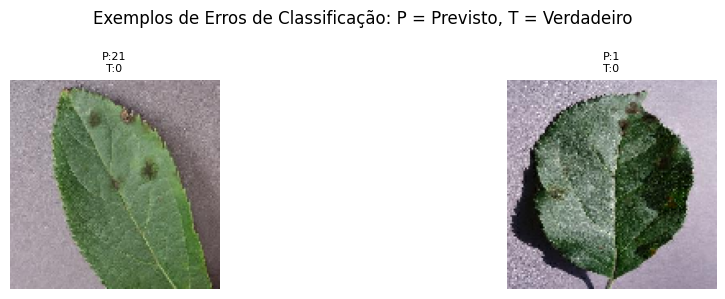

In [ ]:
# Obtém um número maior de amostras para avaliar erros
x_batch, y_batch = next(val_generator)
y_pred_probs = model.predict(x_batch)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_batch.astype(int)

# Encontra índices com erro
erro_indices = np.where(y_pred != y_true)[0]
num_erros = min(len(erro_indices), 12)

# Exibe os erros
plt.figure(figsize=(12, 3))
for i in range(num_erros):
    idx = erro_indices[i]
    plt.subplot(1, num_erros, i + 1)
    plt.imshow(x_batch[idx])
    plt.title(f"P:{y_pred[idx]}\nT:{y_true[idx]}", fontsize=8)
    plt.axis('off')

plt.suptitle("Exemplos de Erros de Classificação: P = Previsto, T = Verdadeiro")
plt.tight_layout()
plt.savefig(error_dir, dpi=300)
plt.show()

340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


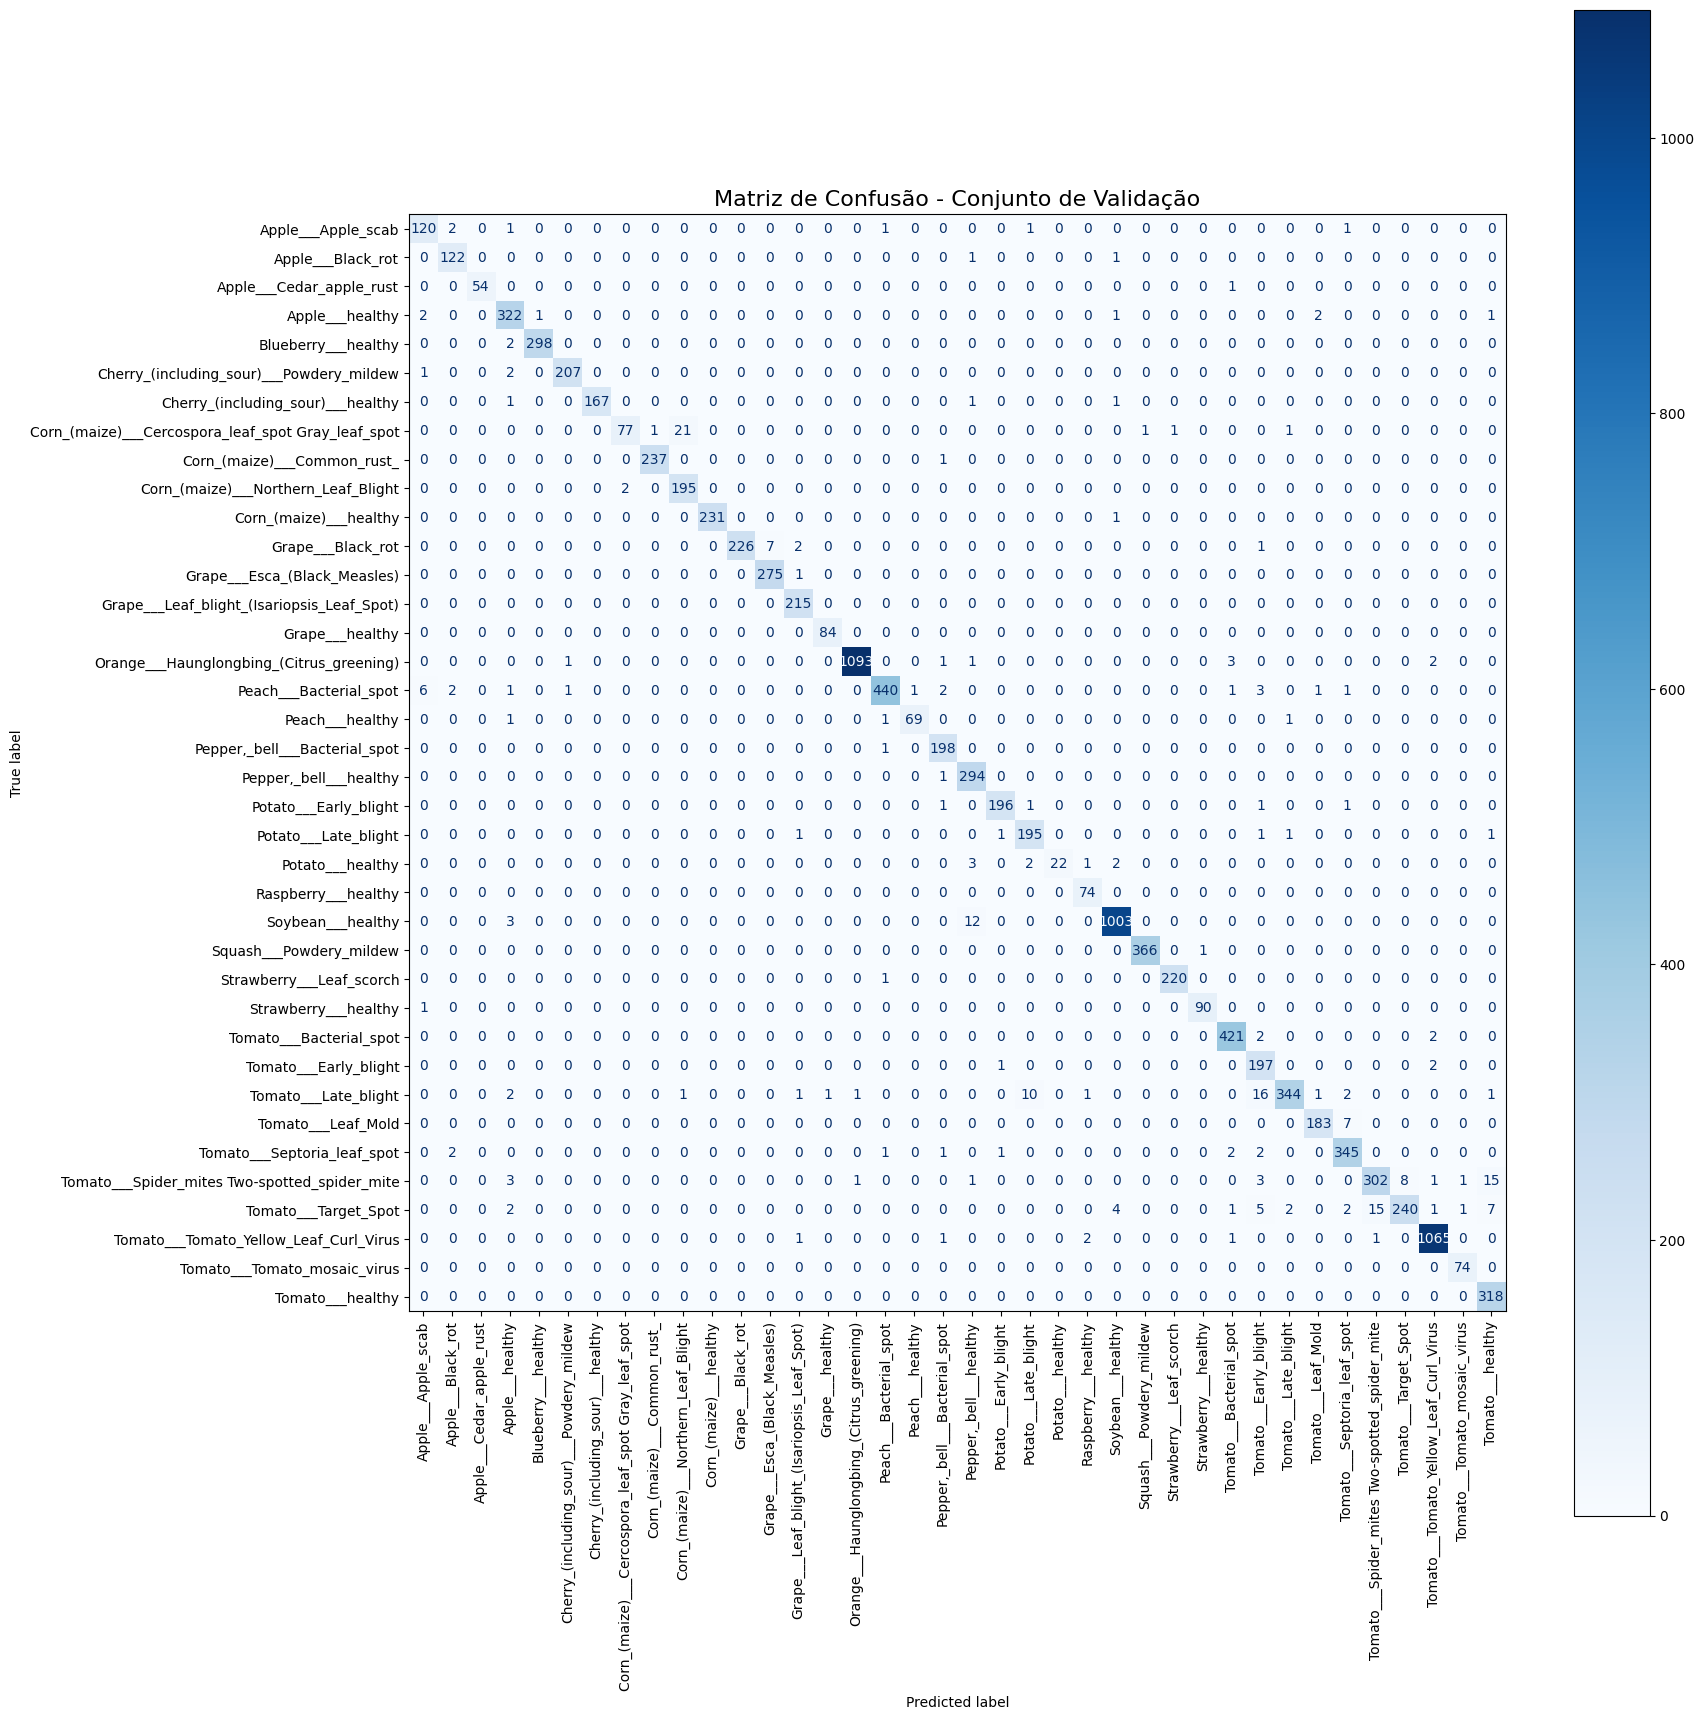

In [ ]:
# Gera as previsões
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# Nomes das classes reais
class_names = list(val_generator.class_indices.keys())

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# Exibe com nomes e layout melhorado
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(18, 18))  # aumenta o tamanho da figura
disp.plot(cmap='Blues', xticks_rotation=90, ax=ax)
plt.title("Matriz de Confusão - Conjunto de Validação", fontsize=16)
plt.tight_layout()
plt.savefig(matrix_dir, dpi=300)
plt.show()

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import requests
from PIL import Image
from io import BytesIO

# Carregar o modelo treinado
model = load_model('/content/drive/MyDrive/Colab Notebooks/CLOROFILA/modelo_60.h5')

# Carregar histórico de treinamento
with open('/content/drive/MyDrive/Colab Notebooks/CLOROFILA/history/history_60.pkl', 'rb') as f:
    history = pickle.load(f)

# Carregar os nomes das classes
class_names = np.load('/content/drive/MyDrive/Colab Notebooks/CLOROFILA/class_names.npy', allow_pickle=True).tolist()

# Definir a função de pré-processamento
def preprocess_local_image(img_path, img_height, img_width):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((img_width, img_height))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # normalizar
    return img_array, img

# Tamanho usado durante o treinamento
img_height = 128
img_width = 128

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


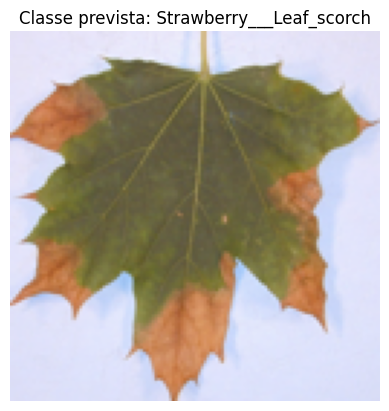

In [14]:
# URL da imagem de teste
image_path = "/content/sample_data/teste6.png"
# Pré-processar a imagem local
img_array, original_img = preprocess_local_image(image_path, img_height, img_width)


# Fazer predição
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]

# Exibir imagem e resultado
plt.imshow(original_img)
plt.title(f'Classe prevista: {predicted_class}')
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


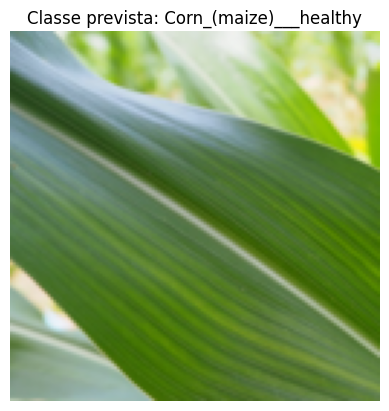

In [15]:
# URL da imagem de teste
image_path = "/content/sample_data/teste7.png"
# Pré-processar a imagem local
img_array, original_img = preprocess_local_image(image_path, img_height, img_width)


# Fazer predição
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]

# Exibir imagem e resultado
plt.imshow(original_img)
plt.title(f'Classe prevista: {predicted_class}')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


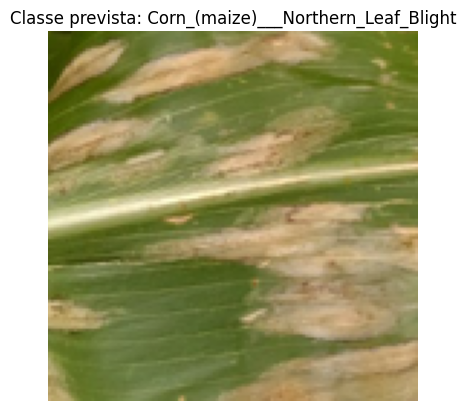

In [17]:
# URL da imagem de teste
image_path = "/content/sample_data/teste9.png"
# Pré-processar a imagem local
img_array, original_img = preprocess_local_image(image_path, img_height, img_width)


# Fazer predição
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]

# Exibir imagem e resultado
plt.imshow(original_img)
plt.title(f'Classe prevista: {predicted_class}')
plt.axis('off')
plt.show()